In [1]:
!pip install nba_api xgboost shap tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.6/322.6 kB 6.6 MB/s eta 0:00:00


In [13]:
from nba_api.stats.endpoints import LeagueGameFinder
import pandas as pd
import time

all_games = []

for start_year in range(1980, 2026):

    season = f"{start_year}-{str(start_year+1)[-2:]}"

    try:
        print(f"Downloading {season}")

        df = LeagueGameFinder(
            season_nullable=season,
            timeout=120
        ).get_data_frames()[0]

        df["SEASON_STR"] = season

        all_games.append(df)

        time.sleep(1)

    except Exception as e:
        print(f"Failed {season}: {e}")

In [14]:
games_df = pd.concat(all_games, ignore_index=True)

print(games_df.shape)

games_df.head()

(109307, 29)


/tmp/ipykernel_1879/1127500913.py:1: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  games_df = pd.concat(all_games, ignore_index=True)


,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,...,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS,SEASON_STR
0,41983,1.610613e+09,BOS,Boston Celtics,0048300079,1984-06-12,BOS vs. LAL,W,240,111,...,20.0,32.0,52.0,18,11.0,3,14,23,NaN,1983-84
1,41983,1.610613e+09,LAL,Los Angeles Lakers,0048300079,1984-06-12,LAL @ BOS,L,240,102,...,9.0,24.0,33.0,28,9.0,8,17,32,NaN,1983-84
2,41983,1.610613e+09,LAL,Los Angeles Lakers,0048300078,1984-06-10,LAL vs. BOS,W,240,119,...,19.0,25.0,44.0,31,9.0,3,14,28,NaN,1983-84
3,41983,1.610613e+09,BOS,Boston Celtics,0048300078,1984-06-10,BOS @ LAL,L,240,108,...,13.0,28.0,41.0,25,7.0,8,19,24,NaN,1983-84
4,41983,1.610613e+09,BOS,Boston Celtics,0048300077,1984-06-08,BOS vs. LAL,W,240,121,...,13.0,38.0,51.0,28,8.0,5,18,32,NaN,1983-84


In [15]:
print(games_df["GAME_DATE"].min())
print(games_df["GAME_DATE"].max())

print(games_df["SEASON_STR"].nunique())

print(sorted(games_df["SEASON_STR"].unique())[:5])
print(sorted(games_df["SEASON_STR"].unique())[-5:])

1983-10-28
2026-06-08
43
['1983-84', '1984-85', '1985-86', '1986-87', '1987-88']
['2021-22', '2022-23', '2023-24', '2024-25', '2025-26']


In [16]:
games_df.to_csv(
    "nba_games_raw.csv",
    index=False
)

In [17]:
games_df["GAME_DATE"] = pd.to_datetime(games_df["GAME_DATE"])

In [18]:
games_df["IS_HOME"] = games_df["MATCHUP"].str.contains("vs.")
games_df["WIN"] = (games_df["WL"] == "W").astype(int)
games_df["LOSS"] = (games_df["WL"] == "L").astype(int)

In [19]:
home = games_df[games_df["IS_HOME"]].copy()
away = games_df[~games_df["IS_HOME"]].copy()

game_level = home.merge(
    away,
    on="GAME_ID",
    suffixes=("_HOME", "_AWAY")
)

In [20]:
print(game_level.shape)
game_level.head()

(54640, 63)


,SEASON_ID_HOME,TEAM_ID_HOME,TEAM_ABBREVIATION_HOME,TEAM_NAME_HOME,GAME_ID,GAME_DATE_HOME,MATCHUP_HOME,WL_HOME,MIN_HOME,PTS_HOME,...,AST_AWAY,STL_AWAY,BLK_AWAY,TOV_AWAY,PF_AWAY,PLUS_MINUS_AWAY,SEASON_STR_AWAY,IS_HOME_AWAY,WIN_AWAY,LOSS_AWAY
0,41983,1.610613e+09,BOS,Boston Celtics,0048300079,1984-06-12,BOS vs. LAL,W,240,111,...,28,9.0,8,17,32,NaN,1983-84,False,0,1
1,41983,1.610613e+09,LAL,Los Angeles Lakers,0048300078,1984-06-10,LAL vs. BOS,W,240,119,...,25,7.0,8,19,24,NaN,1983-84,False,0,1
2,41983,1.610613e+09,BOS,Boston Celtics,0048300077,1984-06-08,BOS vs. LAL,W,240,121,...,20,8.0,8,14,29,NaN,1983-84,False,0,1
3,41983,1.610613e+09,LAL,Los Angeles Lakers,0048300076,1984-06-06,LAL vs. BOS,L,265,125,...,30,15.0,3,14,28,NaN,1983-84,False,1,0
4,41983,1.610613e+09,LAL,Los Angeles Lakers,0048300075,1984-06-03,LAL vs. BOS,W,240,137,...,23,5.0,5,13,33,NaN,1983-84,False,0,1


In [21]:
home_opponent = game_level[
    [
        "SEASON_STR_HOME",
        "TEAM_ID_HOME",
        "PTS_AWAY",
        "FG_PCT_AWAY",
        "FG3_PCT_AWAY"
    ]
].copy()

home_opponent.columns = [
    "SEASON_STR",
    "TEAM_ID",
    "OPP_PTS",
    "OPP_FG_PCT",
    "OPP_FG3_PCT"
]

In [22]:
away_opponent = game_level[
    [
        "SEASON_STR_AWAY",
        "TEAM_ID_AWAY",
        "PTS_HOME",
        "FG_PCT_HOME",
        "FG3_PCT_HOME"
    ]
].copy()

away_opponent.columns = [
    "SEASON_STR",
    "TEAM_ID",
    "OPP_PTS",
    "OPP_FG_PCT",
    "OPP_FG3_PCT"
]

In [23]:
opponent_stats = pd.concat(
    [home_opponent, away_opponent],
    ignore_index=True
)

In [212]:
team_profiles = (
    games_df
    .groupby(
        ["SEASON_STR", "TEAM_ID", "TEAM_NAME"]
    )
    .agg(
        games=("GAME_ID", "count"),

        wins=("WIN", "sum"),
        losses=("LOSS", "sum"),

        ppg=("PTS", "mean"),

        fg_pct=("FG_PCT", "mean"),
        fg3_pct=("FG3_PCT", "mean"),
        ft_pct=("FT_PCT", "mean"),

        fga=("FGA", "mean"),
        fta=("FTA", "mean"),
        fgm=("FGM", "mean"),
        fg3m=("FG3M", "mean"),

        oreb=("OREB", "mean"),
        dreb=("DREB", "mean"),
        reb=("REB", "mean"),

        ast=("AST", "mean"),
        stl=("STL", "mean"),
        blk=("BLK", "mean"),

        tov=("TOV", "mean"),

        plus_minus=("PLUS_MINUS", "mean")
    )
    .reset_index()
)

In [25]:
team_profiles["win_pct"] = (
    team_profiles["wins"]
    /
    team_profiles["games"]
)

In [26]:
home_profiles = (
    games_df[games_df["IS_HOME"]]
    .groupby(
        ["SEASON_STR", "TEAM_ID"]
    )
    .agg(
        home_games=("GAME_ID", "count"),
        home_wins=("WIN", "sum")
    )
    .reset_index()
)

home_profiles["home_losses"] = (
    home_profiles["home_games"]
    -
    home_profiles["home_wins"]
)

home_profiles["home_win_pct"] = (
    home_profiles["home_wins"]
    /
    home_profiles["home_games"]
)

In [27]:
away_profiles = (
    games_df[~games_df["IS_HOME"]]
    .groupby(
        ["SEASON_STR", "TEAM_ID"]
    )
    .agg(
        away_games=("GAME_ID", "count"),
        away_wins=("WIN", "sum")
    )
    .reset_index()
)

away_profiles["away_losses"] = (
    away_profiles["away_games"]
    -
    away_profiles["away_wins"]
)

away_profiles["away_win_pct"] = (
    away_profiles["away_wins"]
    /
    away_profiles["away_games"]
)

In [28]:
opp_profiles = (
    opponent_stats
    .groupby(
        ["SEASON_STR", "TEAM_ID"]
    )
    .agg(
        opp_ppg=("OPP_PTS", "mean"),
        opp_fg_pct=("OPP_FG_PCT", "mean"),
        opp_fg3_pct=("OPP_FG3_PCT", "mean")
    )
    .reset_index()
)

In [29]:
team_profiles = team_profiles.merge(
    home_profiles,
    on=["SEASON_STR", "TEAM_ID"],
    how="left"
)

team_profiles = team_profiles.merge(
    away_profiles,
    on=["SEASON_STR", "TEAM_ID"],
    how="left"
)

team_profiles = team_profiles.merge(
    opp_profiles,
    on=["SEASON_STR", "TEAM_ID"],
    how="left"
)

In [30]:
team_profiles["point_diff"] = (
    team_profiles["ppg"]
    -
    team_profiles["opp_ppg"]
)

team_profiles["fg_pct_diff"] = (
    team_profiles["fg_pct"]
    -
    team_profiles["opp_fg_pct"]
)

team_profiles["fg3_pct_diff"] = (
    team_profiles["fg3_pct"]
    -
    team_profiles["opp_fg3_pct"]
)

In [31]:
team_profiles["playoff_team"] = 0

In [32]:
team_profiles.to_csv(
    "team_profiles.csv",
    index=False
)

print(team_profiles.shape)

team_profiles.head()

(1490, 34)


,SEASON_STR,TEAM_ID,TEAM_NAME,games,wins,losses,ppg,fg_pct,fg3_pct,ft_pct,...,away_wins,away_losses,away_win_pct,opp_ppg,opp_fg_pct,opp_fg3_pct,point_diff,fg_pct_diff,fg3_pct_diff,playoff_team
0,1983-84,1.610613e+09,Atlanta Hawks,87,42,45,101.252874,0.473563,0.233911,0.764977,...,9.0,35.0,0.204545,103.022989,0.483034,0.183446,-1.770115,-0.009471,0.050465,0
1,1983-84,1.610613e+09,Boston Celtics,105,77,28,111.885714,0.496076,0.262344,0.792962,...,32.0,19.0,0.627451,105.933333,0.474695,0.267642,5.952381,0.021381,-0.005298,0
2,1983-84,1.610613e+09,Cleveland Cavaliers,82,28,54,102.512195,0.466171,0.225486,0.745768,...,5.0,36.0,0.121951,107.707317,0.487476,0.249810,-5.195122,-0.021305,-0.024325,0
3,1983-84,1.610613e+09,Chicago Bulls,82,27,55,103.890244,0.476537,0.138966,0.744561,...,9.0,32.0,0.219512,108.97561,0.495707,0.192900,-5.085366,-0.019171,-0.053934,0
4,1983-84,1.610613e+09,Dallas Mavericks,92,47,45,109.445652,0.494587,0.217921,0.763076,...,13.0,33.0,0.282609,110.25,0.501598,0.288650,-0.804348,-0.007011,-0.070729,0


In [56]:
team_profiles.columns.tolist()
team_profiles.shape
#team_profiles.head()

(1225, 42)

In [38]:
sorted(team_profiles["TEAM_NAME"].unique())


[' Global Stars',
 ' OGs',
 ' Rising Stars',
 ' Stars',
 ' Stripes',
 ' Team Austin',
 ' Team C',
 ' Team G League',
 ' Team M',
 ' Team Melo',
 ' Team T',
 ' Team T-Mac',
 ' Team Vince',
 ' World',
 ' Young Stars',
 'Adelaide 36ers',
 'All-Star Giannis',
 'All-Star LeBron',
 'Athens Olympiacos',
 'Atlanta Hawks',
 'Away Away',
 'Barcelona FC Barcelona Lassa',
 'Barcelona FC Barcelona Regal',
 'Barcelona Regal FC',
 'Barcelona Winterthur FC',
 'Bauru Paschoalotto/Bauru',
 'Beijing Ducks',
 'Belegrade Partizan',
 'Berlin Alba Berlin',
 'Bilbao Basket',
 'Boston Celtics',
 'Brisbane Bullets',
 'Brooklyn Nets',
 'Buenos Aires San Lorenzo',
 'Cairns Taipans',
 'Canada Celebrities Canada',
 'Charlotte Bobcats',
 'Charlotte Hornets',
 'Chicago Bulls',
 'China Team China',
 'Cleveland Cavaliers',
 'Clutch City Clutch City',
 'Dallas Mavericks',
 'Denver Nuggets',
 'Detroit Pistons',
 'East Celebrities East',
 'East Dallas Dallas',
 'East NBA All Stars East',
 'East Sunrisers Sunrisers',
 'Fla

In [39]:
nba_teams = {
    'Atlanta Hawks',
    'Boston Celtics',
    'Brooklyn Nets',
    'Charlotte Bobcats',
    'Charlotte Hornets',
    'Chicago Bulls',
    'Cleveland Cavaliers',
    'Dallas Mavericks',
    'Denver Nuggets',
    'Detroit Pistons',
    'Golden State Warriors',
    'Houston Rockets',
    'Indiana Pacers',
    'Kansas City Kings',
    'LA Clippers',
    'Los Angeles Clippers',
    'Los Angeles Lakers',
    'Memphis Grizzlies',
    'Miami Heat',
    'Milwaukee Bucks',
    'Minnesota Timberwolves',
    'New Jersey Nets',
    'New Orleans Hornets',
    'New Orleans/Oklahoma City Hornets',
    'New Orleans Pelicans',
    'New York Knicks',
    'Oklahoma City Thunder',
    'Orlando Magic',
    'Philadelphia 76ers',
    'Phoenix Suns',
    'Portland Trail Blazers',
    'Sacramento Kings',
    'San Antonio Spurs',
    'San Diego Clippers',
    'Seattle SuperSonics',
    'Toronto Raptors',
    'Utah Jazz',
    'Vancouver Grizzlies',
    'Washington Bullets',
    'Washington Wizards'
}

In [40]:
team_profiles = team_profiles[
    team_profiles["TEAM_NAME"].isin(nba_teams)
].copy()

In [41]:
team_profiles.shape

(1225, 34)

In [42]:
print(team_profiles.shape)

print(
    team_profiles.groupby("SEASON_STR")
    ["TEAM_NAME"]
    .nunique()
)

(1225, 34)
SEASON_STR
1983-84    23
1984-85    23
1985-86    23
1986-87    23
1987-88    23
1988-89    25
1989-90    27
1990-91    27
1991-92    27
1992-93    27
1993-94    27
1994-95    27
1995-96    29
1996-97    29
1997-98    29
1998-99    29
1999-00    29
2000-01    29
2001-02    29
2002-03    29
2003-04    29
2004-05    30
2005-06    31
2006-07    31
2007-08    30
2008-09    30
2009-10    30
2010-11    30
2011-12    30
2012-13    30
2013-14    30
2014-15    30
2015-16    30
2016-17    30
2017-18    30
2018-19    30
2019-20    30
2020-21    30
2021-22    30
2022-23    30
2023-24    30
2024-25    30
2025-26    30
Name: TEAM_NAME, dtype: int64


In [43]:
team_profiles.to_csv(
    "team_profiles.csv",
    index=False
)

print(team_profiles.shape)

team_profiles.head()

(1225, 34)


,SEASON_STR,TEAM_ID,TEAM_NAME,games,wins,losses,ppg,fg_pct,fg3_pct,ft_pct,...,away_wins,away_losses,away_win_pct,opp_ppg,opp_fg_pct,opp_fg3_pct,point_diff,fg_pct_diff,fg3_pct_diff,playoff_team
0,1983-84,1.610613e+09,Atlanta Hawks,87,42,45,101.252874,0.473563,0.233911,0.764977,...,9.0,35.0,0.204545,103.022989,0.483034,0.183446,-1.770115,-0.009471,0.050465,0
1,1983-84,1.610613e+09,Boston Celtics,105,77,28,111.885714,0.496076,0.262344,0.792962,...,32.0,19.0,0.627451,105.933333,0.474695,0.267642,5.952381,0.021381,-0.005298,0
2,1983-84,1.610613e+09,Cleveland Cavaliers,82,28,54,102.512195,0.466171,0.225486,0.745768,...,5.0,36.0,0.121951,107.707317,0.487476,0.249810,-5.195122,-0.021305,-0.024325,0
3,1983-84,1.610613e+09,Chicago Bulls,82,27,55,103.890244,0.476537,0.138966,0.744561,...,9.0,32.0,0.219512,108.97561,0.495707,0.192900,-5.085366,-0.019171,-0.053934,0
4,1983-84,1.610613e+09,Dallas Mavericks,92,47,45,109.445652,0.494587,0.217921,0.763076,...,13.0,33.0,0.282609,110.25,0.501598,0.288650,-0.804348,-0.007011,-0.070729,0


In [44]:
team_profiles["assist_turnover_ratio"] = (
    team_profiles["ast"] /
    team_profiles["tov"].replace(0, np.nan)
)

In [45]:
team_profiles["home_away_gap"] = (
    team_profiles["home_win_pct"]
    -
    team_profiles["away_win_pct"]
)

In [46]:
home_opponent_extra = game_level[
    [
        "SEASON_STR_HOME",
        "TEAM_ID_HOME",
        "REB_AWAY",
        "AST_AWAY",
        "TOV_AWAY"
    ]
].copy()

home_opponent_extra.columns = [
    "SEASON_STR",
    "TEAM_ID",
    "OPP_REB",
    "OPP_AST",
    "OPP_TOV"
]

In [47]:
away_opponent_extra = game_level[
    [
        "SEASON_STR_AWAY",
        "TEAM_ID_AWAY",
        "REB_HOME",
        "AST_HOME",
        "TOV_HOME"
    ]
].copy()

away_opponent_extra.columns = [
    "SEASON_STR",
    "TEAM_ID",
    "OPP_REB",
    "OPP_AST",
    "OPP_TOV"
]

In [48]:
opponent_extra = pd.concat(
    [home_opponent_extra, away_opponent_extra],
    ignore_index=True
)

In [49]:
opp_extra_profiles = (
    opponent_extra
    .groupby(
        ["SEASON_STR", "TEAM_ID"]
    )
    .agg(
        opp_reb=("OPP_REB", "mean"),
        opp_ast=("OPP_AST", "mean"),
        opp_tov=("OPP_TOV", "mean")
    )
    .reset_index()
)

In [50]:
team_profiles = team_profiles.merge(
    opp_extra_profiles,
    on=["SEASON_STR", "TEAM_ID"],
    how="left"
)

In [51]:
team_profiles["reb_diff"] = (
    team_profiles["reb"]
    -
    team_profiles["opp_reb"]
)

In [52]:
team_profiles["ast_diff"] = (
    team_profiles["ast"]
    -
    team_profiles["opp_ast"]
)

In [53]:
team_profiles["tov_diff"] = (
    team_profiles["opp_tov"]
    -
    team_profiles["tov"]
)

In [54]:
cols = [
    "assist_turnover_ratio",
    "home_away_gap",
    "opp_reb",
    "opp_ast",
    "opp_tov",
    "reb_diff",
    "ast_diff",
    "tov_diff"
]

team_profiles[cols].describe()

,home_away_gap,opp_reb,reb_diff
count,1225.000000,1225.000000,1225.000000
mean,0.204630,42.801831,-0.065878
std,0.123880,2.270144,2.692019
min,-0.170040,36.568421,-9.621951
25%,0.117465,41.247191,-1.887640
50%,0.201058,42.677778,-0.011236
75%,0.291667,44.290323,1.813333
max,0.624031,52.548780,8.377358


In [55]:
team_profiles.to_csv(
    "team_profiles_v1.csv",
    index=False
)

In [57]:
team_profiles.columns.tolist()

['SEASON_STR',
 'TEAM_ID',
 'TEAM_NAME',
 'games',
 'wins',
 'losses',
 'ppg',
 'fg_pct',
 'fg3_pct',
 'ft_pct',
 'oreb',
 'dreb',
 'reb',
 'ast',
 'stl',
 'blk',
 'tov',
 'plus_minus',
 'win_pct',
 'home_games',
 'home_wins',
 'home_losses',
 'home_win_pct',
 'away_games',
 'away_wins',
 'away_losses',
 'away_win_pct',
 'opp_ppg',
 'opp_fg_pct',
 'opp_fg3_pct',
 'point_diff',
 'fg_pct_diff',
 'fg3_pct_diff',
 'playoff_team',
 'assist_turnover_ratio',
 'home_away_gap',
 'opp_reb',
 'opp_ast',
 'opp_tov',
 'reb_diff',
 'ast_diff',
 'tov_diff']

In [111]:
team_profiles.describe()

,TEAM_ID,games,wins,losses,fg_pct,fg3_pct,ft_pct,oreb,dreb,reb,...,away_losses,away_win_pct,opp_fg_pct,opp_fg3_pct,fg_pct_diff,fg3_pct_diff,playoff_team,home_away_gap,opp_reb,reb_diff
count,1.225000e+03,1225.000000,1225.000000,1225.000000,1225.000000,1225.000000,1225.000000,1225.000000,1225.000000,1225.000000,...,1225.000000,1225.000000,1225.000000,1225.000000,1225.000000,1225.000000,1225.0,1225.000000,1225.000000,1225.000000
mean,1.610613e+09,88.946939,44.515918,44.421224,0.460688,0.338774,0.757601,11.913483,30.823393,42.735953,...,26.817959,0.389622,0.461683,0.340021,-0.000996,-0.001246,0.0,0.204630,42.801831,-0.065878
std,8.581983e+00,10.274483,16.340783,11.205254,0.019610,0.039980,0.029831,1.904110,2.410256,2.121287,...,5.806831,0.149350,0.019250,0.033904,0.022697,0.034061,0.0,0.123880,2.270144,2.692019
min,1.610613e+09,7.000000,2.000000,5.000000,0.403100,0.138966,0.660658,7.363636,24.926829,35.682353,...,10.000000,0.024390,0.402627,0.169722,-0.072268,-0.161989,0.0,-0.170040,36.568421,-9.621951
25%,1.610613e+09,83.000000,32.000000,37.000000,0.446580,0.329029,0.739685,10.490000,29.085366,41.281250,...,23.000000,0.272727,0.448429,0.331135,-0.016953,-0.019930,0.0,0.117465,41.247191,-1.887640
50%,1.610613e+09,89.000000,44.000000,43.000000,0.459782,0.347247,0.759215,11.706667,30.517647,42.700000,...,27.000000,0.395349,0.461118,0.348562,-0.001149,0.000184,0.0,0.201058,42.677778,-0.011236
75%,1.610613e+09,94.000000,56.000000,52.000000,0.473337,0.362733,0.777977,13.105882,32.437500,44.155556,...,31.000000,0.500000,0.474092,0.360978,0.014433,0.019615,0.0,0.291667,44.290323,1.813333
max,1.610613e+09,115.000000,91.000000,77.000000,0.544703,0.423494,0.841784,18.536585,41.637363,50.890110,...,42.000000,0.775510,0.536927,0.398844,0.065762,0.154907,0.0,0.624031,52.548780,8.377358


In [59]:
print(game_level.columns.tolist())

['SEASON_ID_HOME', 'TEAM_ID_HOME', 'TEAM_ABBREVIATION_HOME', 'TEAM_NAME_HOME', 'GAME_ID', 'GAME_DATE_HOME', 'MATCHUP_HOME', 'WL_HOME', 'MIN_HOME', 'PTS_HOME', 'FGM_HOME', 'FGA_HOME', 'FG_PCT_HOME', 'FG3M_HOME', 'FG3A_HOME', 'FG3_PCT_HOME', 'FTM_HOME', 'FTA_HOME', 'FT_PCT_HOME', 'OREB_HOME', 'DREB_HOME', 'REB_HOME', 'AST_HOME', 'STL_HOME', 'BLK_HOME', 'TOV_HOME', 'PF_HOME', 'PLUS_MINUS_HOME', 'SEASON_STR_HOME', 'IS_HOME_HOME', 'WIN_HOME', 'LOSS_HOME', 'SEASON_ID_AWAY', 'TEAM_ID_AWAY', 'TEAM_ABBREVIATION_AWAY', 'TEAM_NAME_AWAY', 'GAME_DATE_AWAY', 'MATCHUP_AWAY', 'WL_AWAY', 'MIN_AWAY', 'PTS_AWAY', 'FGM_AWAY', 'FGA_AWAY', 'FG_PCT_AWAY', 'FG3M_AWAY', 'FG3A_AWAY', 'FG3_PCT_AWAY', 'FTM_AWAY', 'FTA_AWAY', 'FT_PCT_AWAY', 'OREB_AWAY', 'DREB_AWAY', 'REB_AWAY', 'AST_AWAY', 'STL_AWAY', 'BLK_AWAY', 'TOV_AWAY', 'PF_AWAY', 'PLUS_MINUS_AWAY', 'SEASON_STR_AWAY', 'IS_HOME_AWAY', 'WIN_AWAY', 'LOSS_AWAY']


In [60]:
print(game_level.shape)

(54640, 63)


In [61]:
team_profiles["TEAM_KEY"] = (
    team_profiles["SEASON_STR"].astype(str)
    + "_"
    + team_profiles["TEAM_NAME"]
)

In [62]:
game_level["HOME_KEY"] = (
    game_level["SEASON_STR_HOME"].astype(str)
    + "_"
    + game_level["TEAM_NAME_HOME"]
)

In [63]:
game_level["AWAY_KEY"] = (
    game_level["SEASON_STR_AWAY"].astype(str)
    + "_"
    + game_level["TEAM_NAME_AWAY"]
)

In [64]:
game_level["TARGET"] = game_level["WIN_HOME"]

In [65]:
home_profiles = team_profiles.add_prefix("HOME_")

matchups = game_level.merge(
    home_profiles,
    left_on="HOME_KEY",
    right_on="HOME_TEAM_KEY",
    how="left"
)

In [66]:
away_profiles = team_profiles.add_prefix("AWAY_")

matchups = matchups.merge(
    away_profiles,
    left_on="AWAY_KEY",
    right_on="AWAY_TEAM_KEY",
    how="left"
)

In [67]:
matchups.shape

(54640, 152)

In [68]:
matchups[
    [
        "TEAM_NAME_HOME",
        "HOME_win_pct",
        "TEAM_NAME_AWAY",
        "AWAY_win_pct"
    ]
].head()

,TEAM_NAME_HOME,HOME_win_pct,TEAM_NAME_AWAY,AWAY_win_pct
0,Boston Celtics,0.733333,Los Angeles Lakers,0.660194
1,Los Angeles Lakers,0.660194,Boston Celtics,0.733333
2,Boston Celtics,0.733333,Los Angeles Lakers,0.660194
3,Los Angeles Lakers,0.660194,Boston Celtics,0.733333
4,Los Angeles Lakers,0.660194,Boston Celtics,0.733333


In [69]:
matchups.isna().sum().sort_values(ascending=False).head(20)

,0
PLUS_MINUS_AWAY,14833
PLUS_MINUS_HOME,14833
AWAY_plus_minus,14735
HOME_plus_minus,14639
FG3_PCT_HOME,618
FG3_PCT_AWAY,431
AWAY_TEAM_KEY,221
AWAY_ast_diff,221
AWAY_win_pct,221
AWAY_away_losses,221


In [70]:
matchups[
    matchups["AWAY_win_pct"].isna()
][
    [
        "TEAM_NAME_HOME",
        "TEAM_NAME_AWAY",
        "SEASON_STR_HOME"
    ]
].head(30)

,TEAM_NAME_HOME,TEAM_NAME_AWAY,SEASON_STR_HOME
528,West NBA All Stars West,East NBA All Stars East,1983-84
1459,East NBA All Stars East,West NBA All Stars West,1984-85
2473,West NBA All Stars West,East NBA All Stars East,1985-86
3523,East NBA All Stars East,West NBA All Stars West,1986-87
4589,East NBA All Stars East,West NBA All Stars West,1987-88
5595,West NBA All Stars West,East NBA All Stars East,1988-89
6720,East NBA All Stars East,West NBA All Stars West,1989-90
7900,West NBA All Stars West,East NBA All Stars East,1990-91
9078,East NBA All Stars East,West NBA All Stars West,1991-92
10219,West NBA All Stars West,East NBA All Stars East,1992-93


In [71]:
matchups = matchups[
    matchups["HOME_win_pct"].notna()
    &
    matchups["AWAY_win_pct"].notna()
].copy()

In [72]:
nba_teams = set(team_profiles["TEAM_NAME"].unique())

In [73]:
matchups = matchups[
    matchups["TEAM_NAME_HOME"].isin(nba_teams)
    &
    matchups["TEAM_NAME_AWAY"].isin(nba_teams)
].copy()

In [74]:
print(matchups.shape)

(54390, 152)


In [75]:
matchups["TARGET"].value_counts(normalize=True)

,proportion
TARGET,
1,0.602317
0,0.397683


In [76]:
len([c for c in matchups.columns if c.endswith("_diff")])

12

In [77]:
[c for c in matchups.columns if c.endswith("_diff")]

['HOME_point_diff',
 'HOME_fg_pct_diff',
 'HOME_fg3_pct_diff',
 'HOME_reb_diff',
 'HOME_ast_diff',
 'HOME_tov_diff',
 'AWAY_point_diff',
 'AWAY_fg_pct_diff',
 'AWAY_fg3_pct_diff',
 'AWAY_reb_diff',
 'AWAY_ast_diff',
 'AWAY_tov_diff']

In [78]:
matchups.to_csv(
    "matchups.csv",
    index=False
)

print("Saved matchups.csv")

Saved matchups.csv


In [79]:
for col in matchups.columns:
    print(col)

SEASON_ID_HOME
TEAM_ID_HOME
TEAM_ABBREVIATION_HOME
TEAM_NAME_HOME
GAME_ID
GAME_DATE_HOME
MATCHUP_HOME
WL_HOME
MIN_HOME
PTS_HOME
FGM_HOME
FGA_HOME
FG_PCT_HOME
FG3M_HOME
FG3A_HOME
FG3_PCT_HOME
FTM_HOME
FTA_HOME
FT_PCT_HOME
OREB_HOME
DREB_HOME
REB_HOME
AST_HOME
STL_HOME
BLK_HOME
TOV_HOME
PF_HOME
PLUS_MINUS_HOME
SEASON_STR_HOME
IS_HOME_HOME
WIN_HOME
LOSS_HOME
SEASON_ID_AWAY
TEAM_ID_AWAY
TEAM_ABBREVIATION_AWAY
TEAM_NAME_AWAY
GAME_DATE_AWAY
MATCHUP_AWAY
WL_AWAY
MIN_AWAY
PTS_AWAY
FGM_AWAY
FGA_AWAY
FG_PCT_AWAY
FG3M_AWAY
FG3A_AWAY
FG3_PCT_AWAY
FTM_AWAY
FTA_AWAY
FT_PCT_AWAY
OREB_AWAY
DREB_AWAY
REB_AWAY
AST_AWAY
STL_AWAY
BLK_AWAY
TOV_AWAY
PF_AWAY
PLUS_MINUS_AWAY
SEASON_STR_AWAY
IS_HOME_AWAY
WIN_AWAY
LOSS_AWAY
HOME_KEY
AWAY_KEY
TARGET
HOME_SEASON_STR
HOME_TEAM_ID
HOME_TEAM_NAME
HOME_games
HOME_wins
HOME_losses
HOME_ppg
HOME_fg_pct
HOME_fg3_pct
HOME_ft_pct
HOME_oreb
HOME_dreb
HOME_reb
HOME_ast
HOME_stl
HOME_blk
HOME_tov
HOME_plus_minus
HOME_win_pct
HOME_home_games
HOME_home_wins
HOME_home_losses
HO

In [80]:
base_features = [
    "win_pct",

    "home_win_pct",
    "away_win_pct",

    "ppg",
    "opp_ppg",

    "fg_pct",
    "opp_fg_pct",

    "fg3_pct",
    "opp_fg3_pct",

    "ft_pct",

    "reb",
    "ast",
    "stl",
    "blk",
    "tov",

    "point_diff",

    "assist_turnover_ratio",

    "home_away_gap",

    "reb_diff",
    "ast_diff",
    "tov_diff"
]

In [81]:
for feat in base_features:

    matchups[f"{feat}_matchup_diff"] = (
        matchups[f"HOME_{feat}"]
        -
        matchups[f"AWAY_{feat}"]
    )

In [82]:
feature_cols = [
    c for c in matchups.columns
    if c.endswith("_matchup_diff")
]

train_df = matchups[
    feature_cols + ["TARGET"]
].copy()

In [84]:
train_df.shape
train_df.head()

,win_pct_matchup_diff,home_win_pct_matchup_diff,away_win_pct_matchup_diff,ppg_matchup_diff,opp_ppg_matchup_diff,fg_pct_matchup_diff,opp_fg_pct_matchup_diff,fg3_pct_matchup_diff,opp_fg3_pct_matchup_diff,ft_pct_matchup_diff,...,stl_matchup_diff,blk_matchup_diff,tov_matchup_diff,point_diff_matchup_diff,assist_turnover_ratio_matchup_diff,home_away_gap_matchup_diff,reb_diff_matchup_diff,ast_diff_matchup_diff,tov_diff_matchup_diff,TARGET
0,0.073139,0.121795,0.019608,-4.026907,-5.629773,-0.037341,-0.004897,-0.004358,-0.006217,0.047661,...,-0.471012,-0.752936,-1.751919,1.602866,-0.113501,0.102187,2.512344,-1.608784,0.782339,1
1,-0.073139,-0.121795,-0.019608,4.026907,5.629773,0.037341,0.004897,0.004358,0.006217,-0.047661,...,0.471012,0.752936,1.751919,-1.602866,0.113501,-0.102187,-2.512344,1.608784,-0.782339,1
2,0.073139,0.121795,0.019608,-4.026907,-5.629773,-0.037341,-0.004897,-0.004358,-0.006217,0.047661,...,-0.471012,-0.752936,-1.751919,1.602866,-0.113501,0.102187,2.512344,-1.608784,0.782339,1
3,-0.073139,-0.121795,-0.019608,4.026907,5.629773,0.037341,0.004897,0.004358,0.006217,-0.047661,...,0.471012,0.752936,1.751919,-1.602866,0.113501,-0.102187,-2.512344,1.608784,-0.782339,0
4,-0.073139,-0.121795,-0.019608,4.026907,5.629773,0.037341,0.004897,0.004358,0.006217,-0.047661,...,0.471012,0.752936,1.751919,-1.602866,0.113501,-0.102187,-2.512344,1.608784,-0.782339,1


In [85]:
matchups["season_year"] = (
    matchups["SEASON_STR_HOME"]
    .str[:4]
    .astype(int)
)

In [86]:
matchups["season_year"].describe()

,season_year
count,54390.000000
mean,2005.081081
std,12.156291
min,1983.000000
25%,1995.000000
50%,2006.000000
75%,2015.000000
max,2025.000000


In [88]:
feature_cols = [
    c for c in matchups.columns
    if c.endswith("_matchup_diff")
]

In [89]:
train_df = matchups[
    matchups["season_year"] <= 2016
].copy()

valid_df = matchups[
    (matchups["season_year"] >= 2017)
    &
    (matchups["season_year"] <= 2020)
].copy()

test_df = matchups[
    matchups["season_year"] >= 2021
].copy()

In [90]:
print(
    train_df["season_year"].min(),
    train_df["season_year"].max()
)

print(
    valid_df["season_year"].min(),
    valid_df["season_year"].max()
)

print(
    test_df["season_year"].min(),
    test_df["season_year"].max()
)

1983 2016
2017 2020
2021 2025


In [91]:
print("Train:", train_df.shape)
print("Valid:", valid_df.shape)
print("Test :", test_df.shape)

Train: (42254, 174)
Valid: (5222, 174)
Test : (6914, 174)


In [92]:
train_df.to_csv("train.csv", index=False)
valid_df.to_csv("valid.csv", index=False)
test_df.to_csv("test.csv", index=False)

In [93]:
feature_cols = [
    c for c in matchups.columns
    if c.endswith("_matchup_diff")
]

print(len(feature_cols))
print(feature_cols)

21
['win_pct_matchup_diff', 'home_win_pct_matchup_diff', 'away_win_pct_matchup_diff', 'ppg_matchup_diff', 'opp_ppg_matchup_diff', 'fg_pct_matchup_diff', 'opp_fg_pct_matchup_diff', 'fg3_pct_matchup_diff', 'opp_fg3_pct_matchup_diff', 'ft_pct_matchup_diff', 'reb_matchup_diff', 'ast_matchup_diff', 'stl_matchup_diff', 'blk_matchup_diff', 'tov_matchup_diff', 'point_diff_matchup_diff', 'assist_turnover_ratio_matchup_diff', 'home_away_gap_matchup_diff', 'reb_diff_matchup_diff', 'ast_diff_matchup_diff', 'tov_diff_matchup_diff']


In [94]:
feature_cols = [
    'win_pct_matchup_diff',
    'home_win_pct_matchup_diff',
    'away_win_pct_matchup_diff',
    'ppg_matchup_diff',
    'opp_ppg_matchup_diff',
    'fg_pct_matchup_diff',
    'opp_fg_pct_matchup_diff',
    'fg3_pct_matchup_diff',
    'opp_fg3_pct_matchup_diff',
    'ft_pct_matchup_diff',
    'reb_matchup_diff',
    'ast_matchup_diff',
    'stl_matchup_diff',
    'blk_matchup_diff',
    'tov_matchup_diff',
    'point_diff_matchup_diff',
    'assist_turnover_ratio_matchup_diff',
    'home_away_gap_matchup_diff',
    'reb_diff_matchup_diff',
    'ast_diff_matchup_diff',
    'tov_diff_matchup_diff'
]

In [95]:
train_clean = train_df[
    feature_cols + ["TARGET"]
].copy()

valid_clean = valid_df[
    feature_cols + ["TARGET"]
].copy()

test_clean = test_df[
    feature_cols + ["TARGET"]
].copy()

In [96]:
print(train_clean.shape)
print(valid_clean.shape)
print(test_clean.shape)

(42254, 22)
(5222, 22)
(6914, 22)


In [97]:
train_clean.to_csv("train_clean.csv", index=False)
valid_clean.to_csv("valid_clean.csv", index=False)
test_clean.to_csv("test_clean.csv", index=False)

In [98]:
train_clean.describe()


,win_pct_matchup_diff,home_win_pct_matchup_diff,away_win_pct_matchup_diff,fg_pct_matchup_diff,opp_fg_pct_matchup_diff,fg3_pct_matchup_diff,opp_fg3_pct_matchup_diff,ft_pct_matchup_diff,reb_matchup_diff,stl_matchup_diff,home_away_gap_matchup_diff,reb_diff_matchup_diff,TARGET
count,42254.000000,42254.000000,42254.000000,42254.000000,42254.000000,42254.000000,42254.000000,42254.000000,42254.000000,42254.000000,42254.000000,42254.000000,42254.000000
mean,0.000986,0.000735,0.001104,0.000050,-0.000073,0.000079,-0.000081,-0.000001,0.004317,-0.001872,-0.000368,0.009502,0.614711
std,0.207102,0.229156,0.208086,0.020746,0.020226,0.042508,0.027956,0.039218,2.545046,1.291139,0.144534,3.883263,0.486669
min,-0.687073,-0.747186,-0.665882,-0.080044,-0.077884,-0.211670,-0.147685,-0.147967,-11.878049,-5.805816,-0.534314,-14.403560,0.000000
25%,-0.141927,-0.152174,-0.146341,-0.013785,-0.013857,-0.023505,-0.016514,-0.025698,-1.676389,-0.846947,-0.097561,-2.680777,0.000000
50%,0.000508,0.000000,0.000000,0.000036,-0.000100,0.000077,-0.000087,0.000078,0.006382,-0.004521,0.000000,0.007755,1.000000
75%,0.143893,0.153680,0.146909,0.013865,0.013714,0.023601,0.016300,0.025748,1.688552,0.841463,0.096838,2.703869,1.000000
max,0.687073,0.747186,0.665882,0.080044,0.077884,0.211670,0.147685,0.147967,11.878049,5.805816,0.534314,14.403560,1.000000


In [99]:
train_clean[feature_cols].isna().sum()

,0
win_pct_matchup_diff,0
home_win_pct_matchup_diff,0
away_win_pct_matchup_diff,0
ppg_matchup_diff,0
opp_ppg_matchup_diff,0
fg_pct_matchup_diff,0
opp_fg_pct_matchup_diff,0
fg3_pct_matchup_diff,0
opp_fg3_pct_matchup_diff,0
ft_pct_matchup_diff,0


In [211]:
for col in feature_cols:
    # First, try to convert to numeric, coercing errors to NaN
    train_clean[col] = pd.to_numeric(train_clean[col], errors='coerce')
    valid_clean[col] = pd.to_numeric(valid_clean[col], errors='coerce')
    test_clean[col] = pd.to_numeric(test_clean[col], errors='coerce')



X_train = train_clean.drop(columns=["TARGET"])
y_train = train_clean["TARGET"]

X_valid = valid_clean.drop(columns=["TARGET"])
y_valid = valid_clean["TARGET"]

X_test = test_clean.drop(columns=["TARGET"])
y_test = test_clean["TARGET"]

# **LOGISTIC REGRESSION**

In [115]:
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    classification_report
)

In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(X_test)

In [117]:
log_reg = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_reg.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=5000, random_state=42)

In [118]:
valid_prob = log_reg.predict_proba(
    X_valid_scaled
)[:,1]

valid_pred = (
    valid_prob > 0.5
).astype(int)

print(
    "Validation Accuracy:",
    accuracy_score(y_valid, valid_pred)
)

print(
    "Validation ROC-AUC:",
    roc_auc_score(y_valid, valid_prob)
)

print(
    "Validation LogLoss:",
    log_loss(y_valid, valid_prob)
)

Validation Accuracy: 0.6652623515894294
Validation ROC-AUC: 0.726589360050643
Validation LogLoss: 0.6110261218098934


In [119]:
test_prob = log_reg.predict_proba(
    X_test_scaled
)[:,1]

test_pred = (
    test_prob > 0.5
).astype(int)

print(
    "Test Accuracy:",
    accuracy_score(y_test, test_pred)
)

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, test_prob)
)

print(
    "Test LogLoss:",
    log_loss(y_test, test_prob)
)

Test Accuracy: 0.6669077234596471
Test ROC-AUC: 0.7331087340733295
Test LogLoss: 0.6098244321184776


In [120]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "coef": log_reg.coef_[0]
})

importance["abs_coef"] = (
    importance["coef"].abs()
)

importance = importance.sort_values(
    "abs_coef",
    ascending=False
)

importance.head(15)

,feature,coef,abs_coef
0,win_pct_matchup_diff,0.382843,0.382843
2,away_win_pct_matchup_diff,0.369550,0.369550
1,home_win_pct_matchup_diff,0.350067,0.350067
17,home_away_gap_matchup_diff,0.022983,0.022983
5,fg_pct_matchup_diff,0.017202,0.017202
11,ast_matchup_diff,-0.017021,0.017021
19,ast_diff_matchup_diff,0.014509,0.014509
20,tov_diff_matchup_diff,-0.012920,0.012920
12,stl_matchup_diff,0.012168,0.012168
15,point_diff_matchup_diff,-0.009550,0.009550


# **XGBOOST**

In [121]:
!pip install xgboost

In [128]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss
)

In [129]:
X_train = train_clean.drop(columns=["TARGET"])
y_train = train_clean["TARGET"]

X_valid = valid_clean.drop(columns=["TARGET"])
y_valid = valid_clean["TARGET"]

X_test = test_clean.drop(columns=["TARGET"])
y_test = test_clean["TARGET"]

In [130]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"
)

xgb.fit(
    X_train,
    y_train,
    eval_set=[
        (X_valid, y_valid)
    ],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [131]:
valid_prob = xgb.predict_proba(X_valid)[:,1]

valid_pred = (
    valid_prob > 0.5
).astype(int)

print(
    "Validation Accuracy:",
    accuracy_score(y_valid, valid_pred)
)

print(
    "Validation ROC-AUC:",
    roc_auc_score(y_valid, valid_prob)
)

print(
    "Validation LogLoss:",
    log_loss(y_valid, valid_prob)
)

Validation Accuracy: 0.6644963615472999
Validation ROC-AUC: 0.721372431035087
Validation LogLoss: 0.6152032644182269


In [132]:
test_prob = xgb.predict_proba(X_test)[:,1]

test_pred = (
    test_prob > 0.5
).astype(int)

print(
    "Test Accuracy:",
    accuracy_score(y_test, test_pred)
)

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, test_prob)
)

print(
    "Test LogLoss:",
    log_loss(y_test, test_prob)
)

Test Accuracy: 0.673126988718542
Test ROC-AUC: 0.7299141018180112
Test LogLoss: 0.6117907402141352


In [133]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

importance.head(15)

,feature,importance
0,win_pct_matchup_diff,0.376850
15,point_diff_matchup_diff,0.157889
1,home_win_pct_matchup_diff,0.092047
2,away_win_pct_matchup_diff,0.040972
7,fg3_pct_matchup_diff,0.021799
8,opp_fg3_pct_matchup_diff,0.020651
20,tov_diff_matchup_diff,0.019852
17,home_away_gap_matchup_diff,0.019791
12,stl_matchup_diff,0.019730
16,assist_turnover_ratio_matchup_diff,0.019538


In [134]:
drop_features = [
    "win_pct_matchup_diff",
    "home_win_pct_matchup_diff",
    "away_win_pct_matchup_diff"
]

In [135]:
feature_cols_v2 = [
    c for c in feature_cols
    if c not in drop_features
]

print(len(feature_cols_v2))

18


In [141]:
X_train_v2 = train_clean[feature_cols_v2]
X_valid_v2 = valid_clean[feature_cols_v2]
X_test_v2 = test_clean[feature_cols_v2]

y_train = train_clean["TARGET"]
y_valid = valid_clean["TARGET"]
y_test = test_clean["TARGET"]

In [137]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_v2)
X_valid_scaled = scaler.transform(X_valid_v2)
X_test_scaled = scaler.transform(X_test_v2)

log_reg_v2 = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_reg_v2.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=5000, random_state=42)

In [138]:
from sklearn.metrics import accuracy_score, roc_auc_score, log_loss

test_prob = log_reg_v2.predict_proba(X_test_scaled)[:,1]
test_pred = (test_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, test_pred))
print("ROC-AUC :", roc_auc_score(y_test, test_prob))
print("LogLoss :", log_loss(y_test, test_prob))

Accuracy: 0.6650274804743997
ROC-AUC : 0.7241777851504224
LogLoss : 0.6191060332321798


In [152]:
xgb_v2 = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.01,

    max_depth=3,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"
)

xgb_v2.fit(
    X_train_v2,
    y_train,
    eval_set=[(X_valid_v2, y_valid)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [153]:
test_prob = xgb_v2.predict_proba(X_test_v2)[:,1]
test_pred = (test_prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, test_pred))
print("ROC-AUC :", roc_auc_score(y_test, test_prob))
print("LogLoss :", log_loss(y_test, test_prob))

Accuracy: 0.666329187156494
ROC-AUC : 0.724762447543685
LogLoss : 0.6154890028804344


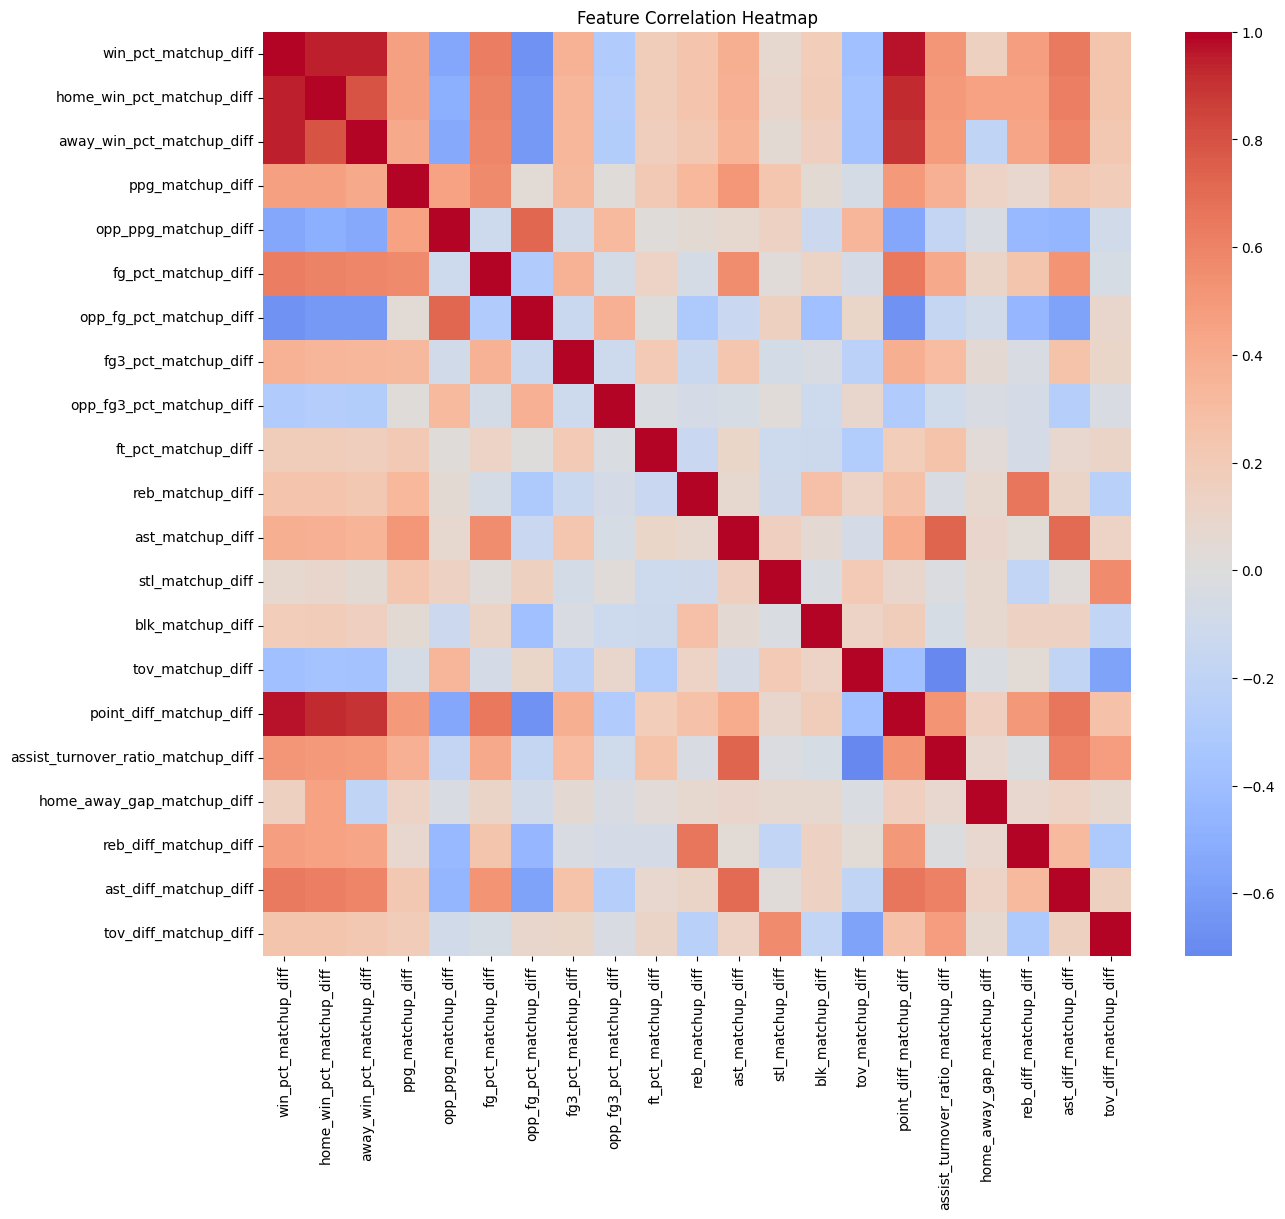

In [154]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = train_clean.drop(columns=["TARGET"]).corr()

plt.figure(figsize=(14,12))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.show()

In [155]:
target_corr = (
    train_clean
    .corr(numeric_only=True)["TARGET"]
    .sort_values(ascending=False)
)

print(target_corr)

TARGET                                1.000000
win_pct_matchup_diff                  0.427707
point_diff_matchup_diff               0.413404
home_win_pct_matchup_diff             0.406220
away_win_pct_matchup_diff             0.401937
ast_diff_matchup_diff                 0.275149
fg_pct_matchup_diff                   0.270515
assist_turnover_ratio_matchup_diff    0.221902
reb_diff_matchup_diff                 0.203889
ppg_matchup_diff                      0.200194
ast_matchup_diff                      0.165187
fg3_pct_matchup_diff                  0.154641
reb_matchup_diff                      0.108318
tov_diff_matchup_diff                 0.103322
blk_matchup_diff                      0.079922
ft_pct_matchup_diff                   0.075073
home_away_gap_matchup_diff            0.065385
stl_matchup_diff                      0.032131
opp_fg3_pct_matchup_diff             -0.125518
tov_matchup_diff                     -0.163781
opp_ppg_matchup_diff                 -0.232196
opp_fg_pct_ma

In [156]:
from sklearn.feature_selection import mutual_info_classif

X = train_clean.drop(columns=["TARGET"])
y = train_clean["TARGET"]

mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_df = (
    pd.DataFrame({
        "feature": X.columns,
        "mi": mi
    })
    .sort_values("mi", ascending=False)
)

print(mi_df)

                               feature        mi
0                 win_pct_matchup_diff  0.099307
2            away_win_pct_matchup_diff  0.090387
1            home_win_pct_matchup_diff  0.090346
15             point_diff_matchup_diff  0.089162
6              opp_fg_pct_matchup_diff  0.054438
5                  fg_pct_matchup_diff  0.053916
19               ast_diff_matchup_diff  0.052770
4                 opp_ppg_matchup_diff  0.046504
18               reb_diff_matchup_diff  0.043113
17          home_away_gap_matchup_diff  0.042193
3                     ppg_matchup_diff  0.042181
16  assist_turnover_ratio_matchup_diff  0.040081
7                 fg3_pct_matchup_diff  0.037117
14                    tov_matchup_diff  0.035884
11                    ast_matchup_diff  0.034585
8             opp_fg3_pct_matchup_diff  0.032557
10                    reb_matchup_diff  0.028777
20               tov_diff_matchup_diff  0.028049
9                  ft_pct_matchup_diff  0.025454
13                  

new features

In [157]:
games_df["POSS"] = (
    games_df["FGA"]
    + 0.44 * games_df["FTA"]
    - games_df["OREB"]
    + games_df["TOV"]
)

In [158]:
games_df["POSS"].describe()

,POSS
count,109303.00
unique,1583.00
top,96.68
freq,339.00


In [214]:
team_profiles_v1_df = pd.read_csv("team_profiles_v1.csv")
print(team_profiles_v1_df.columns.tolist())

['SEASON_STR', 'TEAM_ID', 'TEAM_NAME', 'games', 'wins', 'losses', 'ppg', 'fg_pct', 'fg3_pct', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'plus_minus', 'win_pct', 'home_games', 'home_wins', 'home_losses', 'home_win_pct', 'away_games', 'away_wins', 'away_losses', 'away_win_pct', 'opp_ppg', 'opp_fg_pct', 'opp_fg3_pct', 'point_diff', 'fg_pct_diff', 'fg3_pct_diff', 'playoff_team', 'assist_turnover_ratio', 'home_away_gap', 'opp_reb', 'opp_ast', 'opp_tov', 'reb_diff', 'ast_diff', 'tov_diff']


In [161]:
nba_games_raw_df = pd.read_csv("nba_games_raw.csv")
print(nba_games_raw_df.columns.tolist())

['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID', 'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG_PCT', 'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB', 'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PLUS_MINUS', 'SEASON_STR']


In [162]:
extra_stats = (
    games_df
    .groupby(
        ["SEASON_STR", "TEAM_ID", "TEAM_NAME"]
    )
    .agg(
        fgm=("FGM", "mean"),
        fg3m=("FG3M", "mean"),
        fga=("FGA", "mean"),
        fta=("FTA", "mean"),
        ftm=("FTM", "mean")
    )
    .reset_index()
)

In [163]:
team_profiles_v3 = team_profiles_v1_df.merge(
    extra_stats,
    on=["SEASON_STR", "TEAM_ID", "TEAM_NAME"],
    how="left"
)

In [164]:
team_profiles_v3.shape

(1225, 47)

In [165]:
team_profiles_v3["poss"] = (
    team_profiles_v3["fga"]
    + 0.44 * team_profiles_v3["fta"]
    - team_profiles_v3["oreb"]
    + team_profiles_v3["tov"]
)

In [166]:
team_profiles_v3["pace"] = team_profiles_v3["poss"]

In [167]:
team_profiles_v3["efg_pct"] = (
    team_profiles_v3["fgm"]
    + 0.5 * team_profiles_v3["fg3m"]
) / team_profiles_v3["fga"]

In [168]:
team_profiles_v3["ts_pct"] = (
    team_profiles_v3["ppg"]
    /
    (
        2 *
        (
            team_profiles_v3["fga"]
            + 0.44 * team_profiles_v3["fta"]
        )
    )
)

In [169]:
team_profiles_v3["ortg"] = (
    100 *
    team_profiles_v3["ppg"]
    /
    team_profiles_v3["poss"]
)

In [170]:
team_profiles_v3["drtg"] = (
    100 *
    team_profiles_v3["opp_ppg"]
    /
    team_profiles_v3["poss"]
)

In [171]:
team_profiles_v3["net_rating"] = (
    team_profiles_v3["ortg"]
    -
    team_profiles_v3["drtg"]
)

In [172]:
team_profiles_v3[
    [
        "pace",
        "ortg",
        "drtg",
        "net_rating",
        "efg_pct",
        "ts_pct"
    ]
].describe()

,pace,ortg,drtg,net_rating,efg_pct,ts_pct
count,1225.000000,1225.000000,1225.000000,1225.00000,1225.0,1225.00000
unique,1223.000000,1225.000000,1225.000000,1225.00000,1223.0,1225.00000
top,92.356889,115.240831,111.147791,4.09304,0.5,0.58654
freq,2.000000,1.000000,1.000000,1.00000,3.0,1.00000


In [173]:
print(team_profiles_v3.columns.tolist())

['SEASON_STR', 'TEAM_ID', 'TEAM_NAME', 'games', 'wins', 'losses', 'ppg', 'fg_pct', 'fg3_pct', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'plus_minus', 'win_pct', 'home_games', 'home_wins', 'home_losses', 'home_win_pct', 'away_games', 'away_wins', 'away_losses', 'away_win_pct', 'opp_ppg', 'opp_fg_pct', 'opp_fg3_pct', 'point_diff', 'fg_pct_diff', 'fg3_pct_diff', 'playoff_team', 'assist_turnover_ratio', 'home_away_gap', 'opp_reb', 'opp_ast', 'opp_tov', 'reb_diff', 'ast_diff', 'tov_diff', 'fgm', 'fg3m', 'fga', 'fta', 'ftm', 'poss', 'pace', 'efg_pct', 'ts_pct', 'ortg', 'drtg', 'net_rating']


In [174]:
team_profiles_v3 = team_profiles_v3.apply(
    lambda col: pd.to_numeric(col, errors="ignore")
)

/tmp/ipykernel_1879/643719800.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  lambda col: pd.to_numeric(col, errors="ignore")


In [175]:
team_profiles_v3.select_dtypes(exclude="number").columns

Index(['SEASON_STR', 'TEAM_NAME'], dtype='object')

In [176]:
team_profiles_v3[
    [
        "pace",
        "ortg",
        "drtg",
        "net_rating",
        "efg_pct",
        "ts_pct"
    ]
].describe()

,pace,ortg,drtg,net_rating,efg_pct,ts_pct
count,1225.000000,1225.000000,1225.000000,1225.000000,1225.000000,1225.000000
mean,97.764959,105.259469,105.460360,-0.200891,0.498638,0.541010
std,4.741503,4.537070,4.160021,4.600546,0.027206,0.024274
min,83.974118,89.962195,92.800643,-14.818797,0.424159,0.468458
25%,94.129195,102.125808,102.747217,-3.257487,0.478861,0.524309
50%,97.553258,104.835510,105.193897,0.128904,0.495090,0.538700
75%,101.354157,108.318997,108.056631,3.094328,0.515311,0.557257
max,117.703902,119.937319,119.934561,12.882316,0.573623,0.610860


In [177]:
team_profiles_v3.to_csv(
    "team_profiles_v3.csv",
    index=False
)

print("Saved team_profiles_v3.csv")

Saved team_profiles_v3.csv


In [178]:
print(team_profiles_v3.shape)

team_profiles_v3[
    [
        "SEASON_STR",
        "TEAM_NAME",
        "pace",
        "ortg",
        "drtg",
        "net_rating",
        "efg_pct",
        "ts_pct"
    ]
].head()

(1225, 54)


,SEASON_STR,TEAM_NAME,pace,ortg,drtg,net_rating,efg_pct,ts_pct
0,1983-84,Atlanta Hawks,98.446437,102.850725,104.648773,-1.798049,0.473149,0.526675
1,1983-84,Boston Celtics,103.818667,107.770325,102.036885,5.733440,0.498054,0.551034
2,1983-84,Cleveland Cavaliers,101.370732,101.126029,106.250902,-5.124874,0.467333,0.511538
3,1983-84,Chicago Bulls,103.752683,100.132585,105.034016,-4.901431,0.475734,0.526467
4,1983-84,Dallas Mavericks,102.683043,106.585906,107.369237,-0.783331,0.496374,0.542228


In [179]:
matchups_df = pd.read_csv("matchups.csv")
print(matchups_df.columns.tolist())

['SEASON_ID_HOME', 'TEAM_ID_HOME', 'TEAM_ABBREVIATION_HOME', 'TEAM_NAME_HOME', 'GAME_ID', 'GAME_DATE_HOME', 'MATCHUP_HOME', 'WL_HOME', 'MIN_HOME', 'PTS_HOME', 'FGM_HOME', 'FGA_HOME', 'FG_PCT_HOME', 'FG3M_HOME', 'FG3A_HOME', 'FG3_PCT_HOME', 'FTM_HOME', 'FTA_HOME', 'FT_PCT_HOME', 'OREB_HOME', 'DREB_HOME', 'REB_HOME', 'AST_HOME', 'STL_HOME', 'BLK_HOME', 'TOV_HOME', 'PF_HOME', 'PLUS_MINUS_HOME', 'SEASON_STR_HOME', 'IS_HOME_HOME', 'WIN_HOME', 'LOSS_HOME', 'SEASON_ID_AWAY', 'TEAM_ID_AWAY', 'TEAM_ABBREVIATION_AWAY', 'TEAM_NAME_AWAY', 'GAME_DATE_AWAY', 'MATCHUP_AWAY', 'WL_AWAY', 'MIN_AWAY', 'PTS_AWAY', 'FGM_AWAY', 'FGA_AWAY', 'FG_PCT_AWAY', 'FG3M_AWAY', 'FG3A_AWAY', 'FG3_PCT_AWAY', 'FTM_AWAY', 'FTA_AWAY', 'FT_PCT_AWAY', 'OREB_AWAY', 'DREB_AWAY', 'REB_AWAY', 'AST_AWAY', 'STL_AWAY', 'BLK_AWAY', 'TOV_AWAY', 'PF_AWAY', 'PLUS_MINUS_AWAY', 'SEASON_STR_AWAY', 'IS_HOME_AWAY', 'WIN_AWAY', 'LOSS_AWAY', 'HOME_KEY', 'AWAY_KEY', 'TARGET', 'HOME_SEASON_STR', 'HOME_TEAM_ID', 'HOME_TEAM_NAME', 'HOME_games', '

In [181]:
#print(team_profiles_v3["TEAM_KEY"].head())

print(matchups_df["HOME_TEAM_KEY"].head())

0        1983-84_Boston Celtics
1    1983-84_Los Angeles Lakers
2        1983-84_Boston Celtics
3    1983-84_Los Angeles Lakers
4    1983-84_Los Angeles Lakers
Name: HOME_TEAM_KEY, dtype: object


In [182]:
team_profiles_v3["TEAM_KEY"] = (
    team_profiles_v3["SEASON_STR"]
    + "_"
    + team_profiles_v3["TEAM_NAME"]
)

In [183]:
print(team_profiles_v3["TEAM_KEY"].head())

0          1983-84_Atlanta Hawks
1         1983-84_Boston Celtics
2    1983-84_Cleveland Cavaliers
3          1983-84_Chicago Bulls
4       1983-84_Dallas Mavericks
Name: TEAM_KEY, dtype: object


In [184]:
print(
    matchups_df["HOME_TEAM_KEY"]
    .isin(team_profiles_v3["TEAM_KEY"])
    .mean()
)

print(
    matchups_df["AWAY_TEAM_KEY"]
    .isin(team_profiles_v3["TEAM_KEY"])
    .mean()
)

1.0
1.0


In [185]:
team_profiles_v3.to_csv(
    "team_profiles_v3.csv",
    index=False
)

print("Saved team_profiles_v3.csv")

Saved team_profiles_v3.csv


In [186]:
matchups_v3 = matchups.copy()

In [187]:
new_features = [
    "pace",
    "ortg",
    "drtg",
    "net_rating",
    "efg_pct",
    "ts_pct"
]

In [188]:
profile_cols = ["TEAM_KEY"] + new_features

matchups_v3 = matchups_v3.merge(
    team_profiles_v3[profile_cols],
    left_on="HOME_TEAM_KEY",
    right_on="TEAM_KEY",
    how="left"
)

matchups_v3.rename(
    columns={
        feat: f"HOME_{feat}"
        for feat in new_features
    },
    inplace=True
)

matchups_v3.drop(columns=["TEAM_KEY"], inplace=True)

In [189]:
matchups_v3 = matchups_v3.merge(
    team_profiles_v3[profile_cols],
    left_on="AWAY_TEAM_KEY",
    right_on="TEAM_KEY",
    how="left"
)

matchups_v3.rename(
    columns={
        feat: f"AWAY_{feat}"
        for feat in new_features
    },
    inplace=True
)

matchups_v3.drop(columns=["TEAM_KEY"], inplace=True)

In [190]:
for feat in new_features:

    matchups_v3[f"{feat}_matchup_diff"] = (
        matchups_v3[f"HOME_{feat}"]
        -
        matchups_v3[f"AWAY_{feat}"]
    )

In [191]:
new_diffs = [
    c for c in matchups_v3.columns
    if c.endswith("_matchup_diff")
]

print(len(new_diffs))
print(new_diffs[-10:])

27
['home_away_gap_matchup_diff', 'reb_diff_matchup_diff', 'ast_diff_matchup_diff', 'tov_diff_matchup_diff', 'pace_matchup_diff', 'ortg_matchup_diff', 'drtg_matchup_diff', 'net_rating_matchup_diff', 'efg_pct_matchup_diff', 'ts_pct_matchup_diff']


In [192]:
matchups_v3[
    [
        "HOME_net_rating",
        "AWAY_net_rating",
        "net_rating_matchup_diff"
    ]
].head()

,HOME_net_rating,AWAY_net_rating,net_rating_matchup_diff
0,5.733440,4.099141,1.634299
1,4.099141,5.733440,-1.634299
2,5.733440,4.099141,1.634299
3,4.099141,5.733440,-1.634299
4,4.099141,5.733440,-1.634299


In [193]:
matchups_v3[
    [
        "HOME_net_rating",
        "AWAY_net_rating"
    ]
].isna().sum()

,0
HOME_net_rating,0
AWAY_net_rating,0


In [194]:
matchups_v3.to_csv(
    "matchups_v3.csv",
    index=False
)

print("Saved matchups_v3.csv")

Saved matchups_v3.csv


In [195]:
print(matchups_v3.shape)

matchups_v3.head()

(54390, 192)


,SEASON_ID_HOME,TEAM_ID_HOME,TEAM_ABBREVIATION_HOME,TEAM_NAME_HOME,GAME_ID,GAME_DATE_HOME,MATCHUP_HOME,WL_HOME,MIN_HOME,PTS_HOME,...,AWAY_drtg,AWAY_net_rating,AWAY_efg_pct,AWAY_ts_pct,pace_matchup_diff,ortg_matchup_diff,drtg_matchup_diff,net_rating_matchup_diff,efg_pct_matchup_diff,ts_pct_matchup_diff
0,41983,1.610613e+09,BOS,Boston Celtics,0048300079,1984-06-12,BOS vs. LAL,W,240,111,...,105.141128,4.099141,0.536360,0.574260,-2.289294,-1.469943,-3.104243,1.634299,-0.038306,-0.023226
1,41983,1.610613e+09,LAL,Los Angeles Lakers,0048300078,1984-06-10,LAL vs. BOS,W,240,119,...,102.036885,5.733440,0.498054,0.551034,2.289294,1.469943,3.104243,-1.634299,0.038306,0.023226
2,41983,1.610613e+09,BOS,Boston Celtics,0048300077,1984-06-08,BOS vs. LAL,W,240,121,...,105.141128,4.099141,0.536360,0.574260,-2.289294,-1.469943,-3.104243,1.634299,-0.038306,-0.023226
3,41983,1.610613e+09,LAL,Los Angeles Lakers,0048300076,1984-06-06,LAL vs. BOS,L,265,125,...,102.036885,5.733440,0.498054,0.551034,2.289294,1.469943,3.104243,-1.634299,0.038306,0.023226
4,41983,1.610613e+09,LAL,Los Angeles Lakers,0048300075,1984-06-03,LAL vs. BOS,W,240,137,...,102.036885,5.733440,0.498054,0.551034,2.289294,1.469943,3.104243,-1.634299,0.038306,0.023226


In [196]:
print(matchups_v3.columns.tolist())

['SEASON_ID_HOME', 'TEAM_ID_HOME', 'TEAM_ABBREVIATION_HOME', 'TEAM_NAME_HOME', 'GAME_ID', 'GAME_DATE_HOME', 'MATCHUP_HOME', 'WL_HOME', 'MIN_HOME', 'PTS_HOME', 'FGM_HOME', 'FGA_HOME', 'FG_PCT_HOME', 'FG3M_HOME', 'FG3A_HOME', 'FG3_PCT_HOME', 'FTM_HOME', 'FTA_HOME', 'FT_PCT_HOME', 'OREB_HOME', 'DREB_HOME', 'REB_HOME', 'AST_HOME', 'STL_HOME', 'BLK_HOME', 'TOV_HOME', 'PF_HOME', 'PLUS_MINUS_HOME', 'SEASON_STR_HOME', 'IS_HOME_HOME', 'WIN_HOME', 'LOSS_HOME', 'SEASON_ID_AWAY', 'TEAM_ID_AWAY', 'TEAM_ABBREVIATION_AWAY', 'TEAM_NAME_AWAY', 'GAME_DATE_AWAY', 'MATCHUP_AWAY', 'WL_AWAY', 'MIN_AWAY', 'PTS_AWAY', 'FGM_AWAY', 'FGA_AWAY', 'FG_PCT_AWAY', 'FG3M_AWAY', 'FG3A_AWAY', 'FG3_PCT_AWAY', 'FTM_AWAY', 'FTA_AWAY', 'FT_PCT_AWAY', 'OREB_AWAY', 'DREB_AWAY', 'REB_AWAY', 'AST_AWAY', 'STL_AWAY', 'BLK_AWAY', 'TOV_AWAY', 'PF_AWAY', 'PLUS_MINUS_AWAY', 'SEASON_STR_AWAY', 'IS_HOME_AWAY', 'WIN_AWAY', 'LOSS_AWAY', 'HOME_KEY', 'AWAY_KEY', 'TARGET', 'HOME_SEASON_STR', 'HOME_TEAM_ID', 'HOME_TEAM_NAME', 'HOME_games', '

In [197]:
feature_cols_v3 = [
    c for c in matchups_v3.columns
    if c.endswith("_matchup_diff")
]

print(len(feature_cols_v3))

27


In [198]:
train_v3 = matchups_v3[
    matchups_v3["season_year"] <= 2016
].copy()

valid_v3 = matchups_v3[
    (matchups_v3["season_year"] >= 2017)
    &
    (matchups_v3["season_year"] <= 2020)
].copy()

test_v3 = matchups_v3[
    matchups_v3["season_year"] >= 2021
].copy()

In [199]:
train_clean_v3 = train_v3[
    feature_cols_v3 + ["TARGET"]
].copy()

valid_clean_v3 = valid_v3[
    feature_cols_v3 + ["TARGET"]
].copy()

test_clean_v3 = test_v3[
    feature_cols_v3 + ["TARGET"]
].copy()

In [200]:
train_clean_v3.isna().sum().sort_values(
    ascending=False
).head(20)

,0
win_pct_matchup_diff,0
home_win_pct_matchup_diff,0
away_win_pct_matchup_diff,0
ppg_matchup_diff,0
opp_ppg_matchup_diff,0
fg_pct_matchup_diff,0
opp_fg_pct_matchup_diff,0
fg3_pct_matchup_diff,0
opp_fg3_pct_matchup_diff,0
ft_pct_matchup_diff,0


In [201]:
train_v3.to_csv("train_v3_full.csv", index=False)
valid_v3.to_csv("valid_v3_full.csv", index=False)
test_v3.to_csv("test_v3_full.csv", index=False)

print("Saved full datasets")

Saved full datasets


In [202]:
train_clean_v3.to_csv("train_clean_v3.csv", index=False)
valid_clean_v3.to_csv("valid_clean_v3.csv", index=False)
test_clean_v3.to_csv("test_clean_v3.csv", index=False)

print("Saved clean datasets")

Saved clean datasets


In [203]:
print(train_v3.shape)
print(valid_v3.shape)
print(test_v3.shape)

print(train_clean_v3.shape)
print(valid_clean_v3.shape)
print(test_clean_v3.shape)

(42254, 192)
(5222, 192)
(6914, 192)
(42254, 28)
(5222, 28)
(6914, 28)


In [204]:
from sklearn.feature_selection import mutual_info_classif

X = train_clean_v3.drop(
    columns=["TARGET"]
)

y = train_clean_v3["TARGET"]

mi = mutual_info_classif(
    X,
    y,
    random_state=42
)

mi_df = (
    pd.DataFrame({
        "feature": X.columns,
        "mi": mi
    })
    .sort_values(
        "mi",
        ascending=False
    )
)

print(mi_df.head(15))

                       feature        mi
0         win_pct_matchup_diff  0.099605
24     net_rating_matchup_diff  0.094487
1    home_win_pct_matchup_diff  0.091925
2    away_win_pct_matchup_diff  0.091646
15     point_diff_matchup_diff  0.090096
22           ortg_matchup_diff  0.068506
26         ts_pct_matchup_diff  0.060083
25        efg_pct_matchup_diff  0.057048
23           drtg_matchup_diff  0.056695
6      opp_fg_pct_matchup_diff  0.054359
19       ast_diff_matchup_diff  0.053408
5          fg_pct_matchup_diff  0.053299
4         opp_ppg_matchup_diff  0.045490
3             ppg_matchup_diff  0.042254
17  home_away_gap_matchup_diff  0.042036


In [215]:
X_train = train_clean_v3.drop(columns=["TARGET"])
y_train = train_clean_v3["TARGET"]

X_valid = valid_clean_v3.drop(columns=["TARGET"])
y_valid = valid_clean_v3["TARGET"]

X_test = test_clean_v3.drop(columns=["TARGET"])
y_test = test_clean_v3["TARGET"]

# Ensure all feature columns are numeric and handle any non-numeric values
for col in X_train.columns:
    # Convert to numeric, coercing errors to NaN
    X_train[col] = pd.to_numeric(X_train[col], errors='coerce')
    # Explicitly cast to float type to ensure numeric dtype
    X_train[col] = X_train[col].astype(float)
    # Fill any NaNs that might have been introduced during coercion or were already present
    # Using 0 as a placeholder, as a 'difference' of 0 is a neutral value.
    X_train[col] = X_train[col].fillna(0)

for col in X_valid.columns:
    X_valid[col] = pd.to_numeric(X_valid[col], errors='coerce')
    X_valid[col] = X_valid[col].astype(float)
    X_valid[col] = X_valid[col].fillna(0)

for col in X_test.columns:
    X_test[col] = pd.to_numeric(X_test[col], errors='coerce')
    X_test[col] = X_test[col].astype(float)
    X_test[col] = X_test[col].fillna(0)

print("X_train dtypes after conversion:")
print(X_train.dtypes)
print("X_valid dtypes after conversion:")
print(X_valid.dtypes)
print("X_test dtypes after conversion:")
print(X_test.dtypes)

LR V3

In [206]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [207]:
from sklearn.linear_model import LogisticRegression

log_reg_v3 = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_reg_v3.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=5000, random_state=42)

In [208]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss
)

test_prob = log_reg_v3.predict_proba(
    X_test_scaled
)[:,1]

test_pred = (
    test_prob > 0.5
).astype(int)

print("Accuracy:", accuracy_score(y_test, test_pred))
print("ROC-AUC :", roc_auc_score(y_test, test_prob))
print("LogLoss :", log_loss(y_test, test_prob))

Accuracy: 0.6654613827017646
ROC-AUC : 0.7330813690605744
LogLoss : 0.6098075001871004


In [209]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "coef": log_reg_v3.coef_[0]
})

importance["abs_coef"] = (
    importance["coef"].abs()
)

importance.sort_values(
    "abs_coef",
    ascending=False
).head(15)

,feature,coef,abs_coef
0,win_pct_matchup_diff,0.383057,0.383057
2,away_win_pct_matchup_diff,0.367135,0.367135
1,home_win_pct_matchup_diff,0.348032,0.348032
15,point_diff_matchup_diff,-0.039525,0.039525
3,ppg_matchup_diff,-0.026261,0.026261
17,home_away_gap_matchup_diff,0.023233,0.023233
22,ortg_matchup_diff,0.019046,0.019046
11,ast_matchup_diff,-0.018777,0.018777
25,efg_pct_matchup_diff,0.018038,0.018038
24,net_rating_matchup_diff,0.015647,0.015647


xgb v3

In [216]:
from xgboost import XGBClassifier

xgb_v3 = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_v3.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [217]:
test_prob = xgb_v3.predict_proba(
    X_test
)[:,1]

test_pred = (
    test_prob > 0.5
).astype(int)

print("Accuracy:", accuracy_score(y_test, test_pred))
print("ROC-AUC :", roc_auc_score(y_test, test_prob))
print("LogLoss :", log_loss(y_test, test_prob))

Accuracy: 0.6686433323691061
ROC-AUC : 0.7291993920731099
LogLoss : 0.6126102649689183


In [218]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": xgb_v3.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(15)

,feature,importance
0,win_pct_matchup_diff,0.481722
15,point_diff_matchup_diff,0.048100
1,home_win_pct_matchup_diff,0.037227
24,net_rating_matchup_diff,0.025892
2,away_win_pct_matchup_diff,0.022328
7,fg3_pct_matchup_diff,0.019121
17,home_away_gap_matchup_diff,0.018224
16,assist_turnover_ratio_matchup_diff,0.018134
19,ast_diff_matchup_diff,0.017983
6,opp_fg_pct_matchup_diff,0.017977


In [229]:
basketball_features = [


    "fg_pct_matchup_diff",
    "opp_fg_pct_matchup_diff",

    "fg3_pct_matchup_diff",
    "opp_fg3_pct_matchup_diff",

    "ft_pct_matchup_diff",

    "reb_matchup_diff",
    "ast_matchup_diff",
    "stl_matchup_diff",
    "blk_matchup_diff",
    "tov_matchup_diff",

    "assist_turnover_ratio_matchup_diff",

    "reb_diff_matchup_diff",
    "ast_diff_matchup_diff",
    "tov_diff_matchup_diff",

    "pace_matchup_diff",
    "ortg_matchup_diff",
    "drtg_matchup_diff",
    "efg_pct_matchup_diff",
    "ts_pct_matchup_diff"
]

In [230]:
print(len(basketball_features))

19


In [231]:
X_train_b = train_clean_v3[basketball_features]
y_train = train_clean_v3["TARGET"]

X_valid_b = valid_clean_v3[basketball_features]
y_valid = valid_clean_v3["TARGET"]

X_test_b = test_clean_v3[basketball_features]
y_test = test_clean_v3["TARGET"]

In [232]:
from sklearn.preprocessing import StandardScaler

scaler_b = StandardScaler()

X_train_b_scaled = scaler_b.fit_transform(X_train_b)
X_valid_b_scaled = scaler_b.transform(X_valid_b)
X_test_b_scaled = scaler_b.transform(X_test_b)

In [233]:
from sklearn.linear_model import LogisticRegression

log_b = LogisticRegression(
    max_iter=5000,
    random_state=42
)

log_b.fit(
    X_train_b_scaled,
    y_train
)

LogisticRegression(max_iter=5000, random_state=42)

In [234]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss
)

prob = log_b.predict_proba(
    X_test_b_scaled
)[:,1]

pred = (prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC :", roc_auc_score(y_test, prob))
print("LogLoss :", log_loss(y_test, prob))

Accuracy: 0.6650274804743997
ROC-AUC : 0.7243610375423406
LogLoss : 0.6175775289063947


In [238]:
from xgboost import XGBClassifier

xgb_b = XGBClassifier(
    n_estimators=800,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Ensure all feature columns in X_train_b, X_valid_b, X_test_b are numeric
for col in X_train_b.columns:
    X_train_b[col] = pd.to_numeric(X_train_b[col], errors='coerce').astype(float).fillna(0)
for col in X_valid_b.columns:
    X_valid_b[col] = pd.to_numeric(X_valid_b[col], errors='coerce').astype(float).fillna(0)
for col in X_test_b.columns:
    X_test_b[col] = pd.to_numeric(X_test_b[col], errors='coerce').astype(float).fillna(0)

xgb_b.fit(
    X_train_b,
    y_train,
    eval_set=[(X_valid_b, y_valid)],
    verbose=False
)

/tmp/ipykernel_1879/1637395530.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_b[col] = pd.to_numeric(X_train_b[col], errors='coerce').astype(float).fillna(0)
/tmp/ipykernel_1879/1637395530.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_b[col] = pd.to_numeric(X_train_b[col], errors='coerce').astype(float).fillna(0)
/tmp/ipykernel_1879/1637395530.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=800, n_jobs=None,
              num_parallel_tree=None, ...)

In [239]:
prob = xgb_b.predict_proba(
    X_test_b
)[:,1]

pred = (prob > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC :", roc_auc_score(y_test, prob))
print("LogLoss :", log_loss(y_test, prob))

Accuracy: 0.6658952849291293
ROC-AUC : 0.7240210505572422
LogLoss : 0.6150302557904606


In [240]:
importance = pd.DataFrame({
    "feature": X_train_b.columns,
    "importance": xgb_b.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(15)

,feature,importance
15,ortg_matchup_diff,0.223576
16,drtg_matchup_diff,0.163001
18,ts_pct_matchup_diff,0.150222
1,opp_fg_pct_matchup_diff,0.120676
12,ast_diff_matchup_diff,0.081052
17,efg_pct_matchup_diff,0.056082
10,assist_turnover_ratio_matchup_diff,0.026844
0,fg_pct_matchup_diff,0.022019
11,reb_diff_matchup_diff,0.019782
2,fg3_pct_matchup_diff,0.016626


In [241]:
import joblib

In [242]:
deployment_bundle = {
    "model": xgb_b,
    "features": basketball_features
}

joblib.dump(
    deployment_bundle,
    "nba_historical_simulator.pkl"
)

['nba_historical_simulator.pkl']

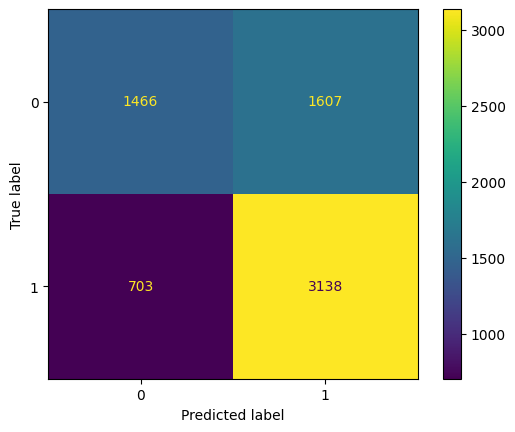

In [244]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay(cm).plot()

plt.show()

In [245]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(
    y_test,
    prob
)

print("Brier Score:", brier)


Brier Score: 0.2124593111589438


In [246]:

from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_test,
    prob,
    n_bins=10
)

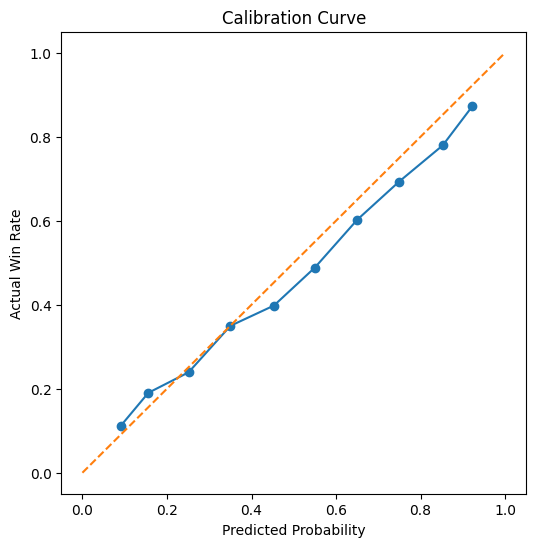

In [247]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o"
)

plt.plot(
    [0,1],
    [0,1],
    "--"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Win Rate")

plt.title("Calibration Curve")

plt.show()

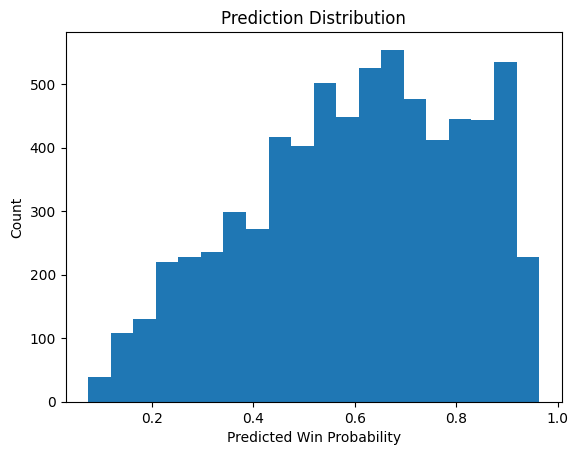

In [248]:
import matplotlib.pyplot as plt

plt.hist(
    prob,
    bins=20
)

plt.xlabel("Predicted Win Probability")
plt.ylabel("Count")

plt.title("Prediction Distribution")

plt.show()

In [249]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_xgb = CalibratedClassifierCV(
    xgb_b,
    method="isotonic",
    cv="prefit"
)

calibrated_xgb.fit(
    X_valid_b,
    y_valid
)

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


CalibratedClassifierCV(cv='prefit',
                       estimator=XGBClassifier(base_score=None, booster=None,
                                               callbacks=None,
                                               colsample_bylevel=None,
                                               colsample_bynode=None,
                                               colsample_bytree=0.8,
                                               device=None,
                                               early_stopping_rounds=None,
                                               enable_categorical=False,
                                               eval_metric='logloss',
                                               feature_types=None,
                                               feature_weights=None, gamma=None,
                                               grow_policy=None,
                                               importance_type=None,
                                               interaction_constraints=None,
                                               learning_rate=0.01, max_bin=None,
                                               max_cat_threshold=None,
                                               max_cat_to_onehot=None,
                                               max_delta_step=None, max_depth=3,
                                               max_leaves=None,
                                               min_child_weight=None,
                                               missing=nan,
                                               monotone_constraints=None,
                                               multi_strategy=None,
                                               n_estimators=800, n_jobs=None,
                                               num_parallel_tree=None, ...),
                       method='isotonic')

In [250]:
prob_cal = calibrated_xgb.predict_proba(
    X_test_b
)[:,1]

In [252]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    log_loss,
    brier_score_loss,
    confusion_matrix
)

# Probabilities
prob_cal = calibrated_xgb.predict_proba(X_test_b)[:, 1]

# Predictions
pred_cal = (prob_cal > 0.5).astype(int)

# Metrics
print("Accuracy   :", accuracy_score(y_test, pred_cal))
print("ROC-AUC    :", roc_auc_score(y_test, prob_cal))
print("LogLoss    :", log_loss(y_test, prob_cal))
print("Brier Score:", brier_score_loss(y_test, prob_cal))

# Confusion Matrix
cm = confusion_matrix(y_test, pred_cal)

print("\nConfusion Matrix:")
print(cm)

Accuracy   : 0.666329187156494
ROC-AUC    : 0.7230003271093319
LogLoss    : 0.6181670988048479
Brier Score: 0.2104577331664254

Confusion Matrix:
[[1842 1231]
 [1076 2765]]


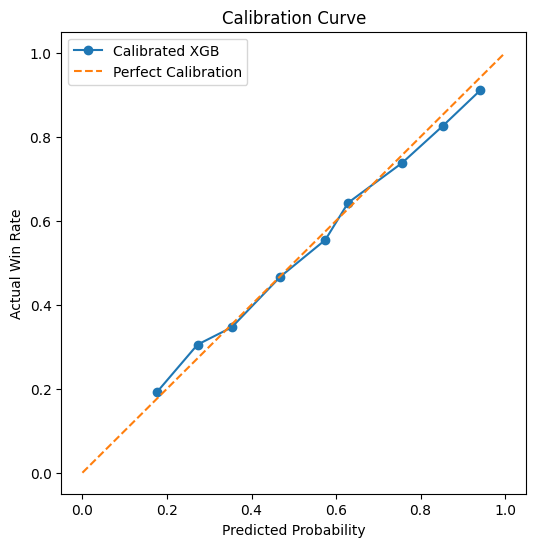

In [253]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(
    y_test,
    prob_cal,
    n_bins=10
)

plt.figure(figsize=(6,6))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="Calibrated XGB"
)

plt.plot(
    [0,1],
    [0,1],
    "--",
    label="Perfect Calibration"
)

plt.xlabel("Predicted Probability")
plt.ylabel("Actual Win Rate")
plt.title("Calibration Curve")
plt.legend()

plt.show()

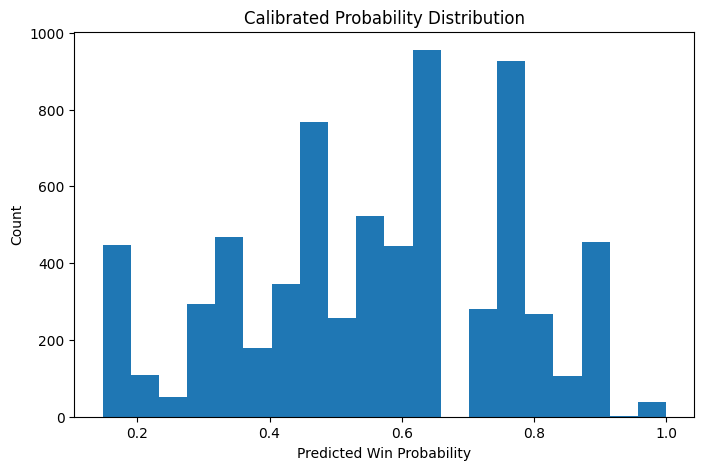

In [254]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    prob_cal,
    bins=20
)

plt.xlabel("Predicted Win Probability")
plt.ylabel("Count")
plt.title("Calibrated Probability Distribution")

plt.show()

In [255]:
from sklearn.metrics import accuracy_score

for t in [0.40,0.45,0.50,0.55,0.60]:
    pred = (prob_cal > t).astype(int)

    acc = accuracy_score(
        y_test,
        pred
    )

    print(f"Threshold={t:.2f}  Accuracy={acc:.4f}")

Threshold=0.40  Accuracy=0.6532
Threshold=0.45  Accuracy=0.6620
Threshold=0.50  Accuracy=0.6663
Threshold=0.55  Accuracy=0.6663
Threshold=0.60  Accuracy=0.6511


In [256]:
import joblib


deployment_bundle = {
    "model": calibrated_xgb,
    "features": basketball_features
}

joblib.dump(
    deployment_bundle,
    "nba_historical_simulator.pkl"
)

['nba_historical_simulator.pkl']

In [257]:
import json

with open(
    "feature_names.json",
    "w"
) as f:
    json.dump(
        basketball_features,
        f,
        indent=2
    )